In [ ]:
import os
import zipfile

BASE_DIR = r"C:\Users\96277\Desktop\LIVER_PROJECT\3Dircadb1"

def unzip_all_files():
    for root, dirs, files in os.walk(BASE_DIR):
        for file in files:
            if file.endswith(".zip"):
                zip_path = os.path.join(root, file)
                extract_path = root

                print(f"Extracting: {file} ...")

                try:
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(extract_path)
                    print("Extraction completed successfully.")
                except Exception as e:
                    print(f"Error in file {file}: {e}")

if __name__ == "__main__":
    print("Starting extraction process...")
    unzip_all_files()
    print("All files have been extracted. Ready to proceed.")


Starting extraction process...
All files have been extracted. Ready to proceed.


In [3]:
!pip install pydicom


  Using cached pydicom-3.0.1-py3-none-any.whl.metadata (9.4 kB)
Using cached pydicom-3.0.1-py3-none-any.whl (2.4 MB)


Opening ZIP file: PATIENT_DICOM.zip
Reading DICOM file: PATIENT_DICOM/image_0
------------------------------
File read successfully.
Patient ID: 
Image dimensions: 512 x 512
Slice position (Z-axis): 0
------------------------------


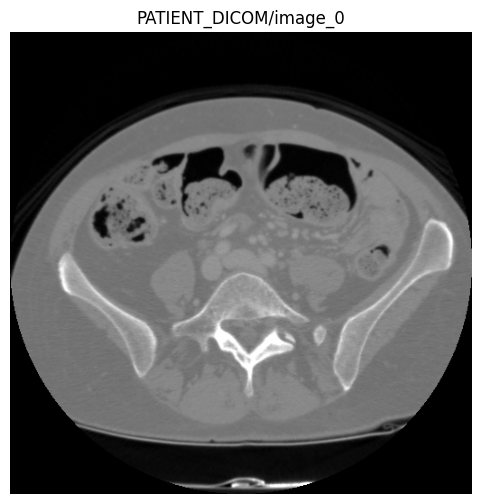

In [ ]:
#This part of the code is used to verify the integrity of medical data
#before any processing or training begins,
#where we read the DICOM file and visually view it to detect any early problems in the data.

# Slice position (Z-axis)
'''
image_0  ← أسفل البطن
image_1
image_2
image_3
image_4  ← أعلى البطن

'''

import zipfile
import pydicom
import matplotlib.pyplot as plt
import os

zip_path = r"C:\Users\96277\Desktop\Liver_Project\3Dircadb1\3Dircadb1\3Dircadb1.1\PATIENT_DICOM.zip"

print(f"Opening ZIP file: {os.path.basename(zip_path)}")

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        dicom_files = [f for f in zip_ref.namelist() if not f.endswith("/")]

        if len(dicom_files) == 0:
            raise ValueError("No files found inside the ZIP archive.")

        dicom_name = dicom_files[0]
        print(f"Reading DICOM file: {dicom_name}")

        with zip_ref.open(dicom_name) as dicom_file:
            dataset = pydicom.dcmread(dicom_file)

    print("-" * 30)
    print("File read successfully.")
    print(f"Patient ID: {dataset.PatientID}")
    print(f"Image dimensions: {dataset.Rows} x {dataset.Columns}")

    if 'ImagePositionPatient' in dataset:
        print(f"Slice position (Z-axis): {dataset.ImagePositionPatient[2]}")
    else:
        print("Warning: No image position information found.")

    print("-" * 30)

    plt.figure(figsize=(6, 6))
    plt.imshow(dataset.pixel_array, cmap='gray')
    plt.title(dicom_name)
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")


Starting data processing...
Loading CT volume...
Loading liver mask...
Liver mask found at: C:\Users\96277\Desktop\Liver_Project\3Dircadb1\3Dircadb1\3Dircadb1.1\MASKS_DICOM\MASKS_DICOM\liver
Searching for tumor masks...
Loading completed. Preparing visualization...


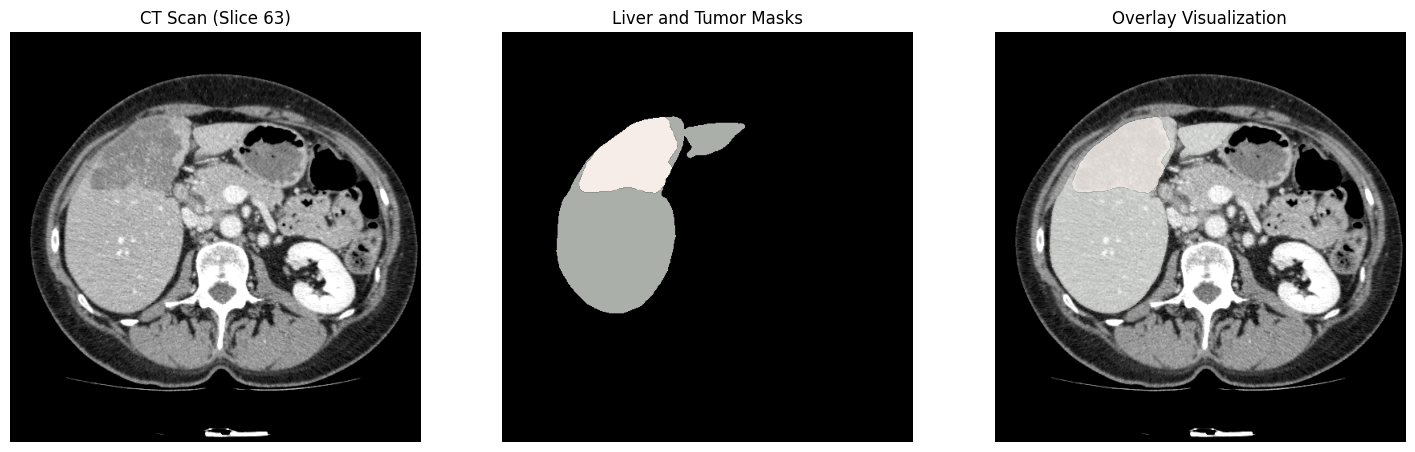

In [ ]:
import os
import zipfile
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from glob import glob

PATIENT_PATH = r"C:\Users\96277\Desktop\Liver_Project\3Dircadb1\3Dircadb1\3Dircadb1.1"

def unzip_if_needed(zip_name, folder_name):
    zip_path = os.path.join(PATIENT_PATH, zip_name)
    folder_path = os.path.join(PATIENT_PATH, folder_name)

    if not os.path.exists(zip_path):
        print(f"Warning: ZIP file {zip_name} not found.")
        return

    if not os.path.exists(folder_path):
        print(f"Extracting {zip_name}...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(PATIENT_PATH)
        print("Extraction completed.")

def load_volume_sorted(folder_path):
    if not os.path.exists(folder_path):
        return None

    files = glob(os.path.join(folder_path, "*"))
    dicom_files = [f for f in files if os.path.isfile(f)]

    if not dicom_files:
        return None

    slices = []
    for f in dicom_files:
        try:
            ds = pydicom.dcmread(f, force=True)
            if hasattr(ds, "pixel_array"):
                slices.append(ds)
        except:
            continue

    if not slices:
        return None

    def sort_key(ds):
        if hasattr(ds, "ImagePositionPatient"):
            return float(ds.ImagePositionPatient[2])
        elif hasattr(ds, "InstanceNumber"):
            return int(ds.InstanceNumber)
        else:
            return 0

    slices.sort(key=sort_key)
    volume = np.stack([s.pixel_array for s in slices])
    return volume

def apply_windowing(image, level=40, window=350):
    min_hu = level - window // 2
    max_hu = level + window // 2
    image = np.clip(image, min_hu, max_hu)
    image = (image - min_hu) / (max_hu - min_hu)
    return image

print("Starting data processing...")

unzip_if_needed("PATIENT_DICOM.zip", "PATIENT_DICOM")
unzip_if_needed("MASKS_DICOM.zip", "MASKS_DICOM")

print("Loading CT volume...")
ct_path = os.path.join(PATIENT_PATH, "PATIENT_DICOM")
if os.path.exists(os.path.join(ct_path, "PATIENT_DICOM")):
    ct_path = os.path.join(ct_path, "PATIENT_DICOM")

ct_vol = load_volume_sorted(ct_path)

print("Loading liver mask...")
base_masks_path = os.path.join(PATIENT_PATH, "MASKS_DICOM")
potential_liver_paths = [
    os.path.join(base_masks_path, "liver"),
    os.path.join(base_masks_path, "MASKS_DICOM", "liver"),
    os.path.join(base_masks_path, "MASKS", "liver")
]

liver_vol = None
current_masks_dir = None

for path in potential_liver_paths:
    if os.path.exists(path):
        print(f"Liver mask found at: {path}")
        liver_vol = load_volume_sorted(path)
        current_masks_dir = os.path.dirname(path)
        break

if ct_vol is None or liver_vol is None:
    print("Error: Failed to load CT or liver volume.")
    print(f"CT status: {'Loaded' if ct_vol is not None else 'Failed'}")
    print(f"Liver status: {'Loaded' if liver_vol is not None else 'Failed'}")
    exit()

print("Searching for tumor masks...")
tumor_vol = np.zeros_like(liver_vol)

if current_masks_dir:
    tumor_folders = glob(os.path.join(current_masks_dir, "livertumor*"))
    for t_folder in tumor_folders:
        t_vol = load_volume_sorted(t_folder)
        if t_vol is not None:
            tumor_vol = np.maximum(tumor_vol, t_vol)

print("Loading completed. Preparing visualization...")

sums = np.sum(tumor_vol, axis=(1, 2))
best_slice_idx = int(np.argmax(sums)) if np.max(sums) > 0 else len(ct_vol) // 2

slice_img = ct_vol[best_slice_idx]
slice_liver = liver_vol[best_slice_idx]
slice_tumor = tumor_vol[best_slice_idx]
slice_img_windowed = apply_windowing(slice_img)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title(f"CT Scan (Slice {best_slice_idx})")
plt.imshow(slice_img_windowed, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Liver and Tumor Masks")
plt.imshow(np.zeros_like(slice_img), cmap="gray")
plt.imshow(np.ma.masked_where(slice_liver == 0, slice_liver), cmap="Greens", alpha=0.7)
plt.imshow(np.ma.masked_where(slice_tumor == 0, slice_tumor), cmap="Reds", alpha=0.9)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay Visualization")
plt.imshow(slice_img_windowed, cmap="gray")
plt.imshow(np.ma.masked_where(slice_liver == 0, slice_liver), cmap="Greens", alpha=0.3)
plt.imshow(np.ma.masked_where(slice_tumor == 0, slice_tumor), cmap="Reds", alpha=0.6)
plt.axis("off")

plt.show()


In [ ]:
import os
import pydicom
import numpy as np
import zipfile
from glob import glob

BASE_PATH = r"C:\Users\96277\Desktop\LIVER_PROJECT\3Dircadb1\3Dircadb1" 
OUTPUT_PATH = "processed_data_2d"

def extract_all_zips(patient_path):
    zip_files = glob(os.path.join(patient_path, "*.zip"))
    for zip_file in zip_files:
        folder_name = os.path.basename(zip_file).replace(".zip", "")
        extract_to = os.path.join(patient_path, folder_name)
        if not os.path.exists(extract_to):
            try:
                with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                    zip_ref.extractall(patient_path)
            except Exception as e:
                print(f"Error extracting {zip_file}: {e}")

def find_actual_folder(base_path, target_name):
    search_pattern = os.path.join(base_path, "**", target_name)
    found_folders = glob(search_pattern, recursive=True)
    for folder in found_folders:
        if os.path.isdir(folder):
            if any(os.path.isfile(os.path.join(folder, f)) for f in os.listdir(folder)):
                return folder
    return None

def load_dicom_volume(folder_path):
    if folder_path is None or not os.path.exists(folder_path):
        return None
    files = glob(os.path.join(folder_path, "*"))
    dicom_files = [f for f in files if os.path.isfile(f) and not f.endswith(('.txt', '.jpg', '.zip'))]
    if not dicom_files: return None
    slices = []
    for f in dicom_files:
        try:
            ds = pydicom.dcmread(f, force=True)
            if hasattr(ds, 'pixel_array'):
                slices.append(ds)
        except: continue
    if not slices: return None
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]) if hasattr(x, "ImagePositionPatient") else 0)
    return np.stack([s.pixel_array for s in slices]).astype(np.float32)

def window_image(image, min_hu=-100, max_hu=400):
    image = np.clip(image, min_hu, max_hu)
    image = (image - min_hu) / (max_hu - min_hu)
    return image

if __name__ == "__main__":
    os.makedirs(os.path.join(OUTPUT_PATH, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, "masks"), exist_ok=True)

    patient_folders = sorted(glob(os.path.join(BASE_PATH, "3Dircadb1.*")))
    print(f"Found {len(patient_folders)} patients. Starting processing...")

    total_slices = 0
    for patient_path in patient_folders:
        try:
            p_id = os.path.basename(patient_path)
            print(f"--- Processing {p_id} ---")
            
            extract_all_zips(patient_path)
            
            ct_dir = find_actual_folder(patient_path, "PATIENT_DICOM")
            ct_vol = load_dicom_volume(ct_dir)
            
            if ct_vol is None:
                print(f"Skipping {p_id}: CT volume not found after extraction.")
                continue
            
            mask_vol = np.zeros(ct_vol.shape, dtype=np.uint8)
            liver_dir = find_actual_folder(patient_path, "liver")
            
            if liver_dir:
                l_vol = load_dicom_volume(liver_dir)
                if l_vol is not None and l_vol.shape == ct_vol.shape:
                    mask_vol[l_vol > 0] = 1
            
            if liver_dir:
                masks_parent_dir = os.path.dirname(liver_dir)
                tumor_paths = glob(os.path.join(masks_parent_dir, "livertumor*"))
                for t_path in tumor_paths:
                    t_vol = load_dicom_volume(t_path)
                    if t_vol is not None and t_vol.shape == ct_vol.shape:
                        mask_vol[t_vol > 0] = 2

            saved = 0
            for i in range(ct_vol.shape[0]):
                if np.sum(mask_vol[i]) > 0: 
                    img = window_image(ct_vol[i])
                    np.save(os.path.join(OUTPUT_PATH, "images", f"{p_id}_{i}.npy"), img)
                    np.save(os.path.join(OUTPUT_PATH, "masks", f"{p_id}_{i}.npy"), mask_vol[i])
                    saved += 1
            
            print(f"Saved {saved} slices.")
            total_slices += saved
            
        except Exception as e:
            print(f"Error in {p_id}: {e}")

    print(f"\nProcessing complete! Total slices: {total_slices}")

Found 20 patients. Starting processing...
--- Processing 3Dircadb1.1 ---
Saved 98 slices.
--- Processing 3Dircadb1.10 ---
Saved 99 slices.
--- Processing 3Dircadb1.11 ---
Saved 96 slices.
--- Processing 3Dircadb1.12 ---
Saved 239 slices.
--- Processing 3Dircadb1.13 ---
Saved 90 slices.
--- Processing 3Dircadb1.14 ---
Saved 104 slices.
--- Processing 3Dircadb1.15 ---
Saved 115 slices.
--- Processing 3Dircadb1.16 ---
Saved 113 slices.
--- Processing 3Dircadb1.17 ---
Saved 113 slices.
--- Processing 3Dircadb1.18 ---
Saved 59 slices.
--- Processing 3Dircadb1.19 ---
Saved 41 slices.
--- Processing 3Dircadb1.2 ---
Saved 114 slices.
--- Processing 3Dircadb1.20 ---
Saved 85 slices.
--- Processing 3Dircadb1.3 ---
Saved 123 slices.
--- Processing 3Dircadb1.4 ---
Saved 67 slices.
--- Processing 3Dircadb1.5 ---
Saved 119 slices.
--- Processing 3Dircadb1.6 ---
Saved 96 slices.
--- Processing 3Dircadb1.7 ---
Saved 98 slices.
--- Processing 3Dircadb1.8 ---
Saved 116 slices.
--- Processing 3Dircadb1.9